In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)



In [17]:
data=load_breast_cancer()
X=data.data
y=data.target
print("Dataset Shape:",X.shape)
print("Classes:",np.unique(y))

Dataset Shape: (569, 30)
Classes: [0 1]


In [18]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [19]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [23]:
mle_model=LogisticRegression(
    penalty=None,
    max_iter=5000,
    random_state=42
)
mle_model.fit(X_train,y_train)
y_pred_mle=mle_model.predict(X_test)


In [29]:
map_l2=LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)
map_l2.fit(X_train,y_train)
y_pred_l2=map_l2.predict(X_test)

In [31]:
map_l1=LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    max_iter=5000,
    random_state=42,
)
map_l1.fit(X_train,y_train)
y_pred_l1=map_l1.predict(X_test)

In [38]:
def evaluate(model_name,y_true,y_pred):
    print("\n","="*40)
    print(model_name)
    print("="*40)

    print("Accuracy  :", accuracy_score(y_true,y_pred))
    print("Prescision:",precision_score(y_true,y_pred))
    print("recall    :",recall_score(y_true,y_pred))
    print("F1 Score  :",f1_score(y_true,y_pred))

    print("\nconfusion martix")
    print(confusion_matrix(y_true,y_pred))
    

In [41]:
evaluate("MLE",y_test,y_pred_mle)

evaluate("MAP (L2)",y_test,y_pred_l2)

evaluate("MAP (L1)",y_test,y_pred_l1)


MLE
Accuracy  : 0.9210526315789473
Prescision: 0.9701492537313433
recall    : 0.9027777777777778
F1 Score  : 0.935251798561151

confusion martix
[[40  2]
 [ 7 65]]

MAP (L2)
Accuracy  : 0.9824561403508771
Prescision: 0.9861111111111112
recall    : 0.9861111111111112
F1 Score  : 0.9861111111111112

confusion martix
[[41  1]
 [ 1 71]]

MAP (L1)
Accuracy  : 0.9912280701754386
Prescision: 0.9863013698630136
recall    : 1.0
F1 Score  : 0.993103448275862

confusion martix
[[41  1]
 [ 0 72]]


In [44]:
print("Number of Zero Coefficients")
print("MLE    :",np.sum(mle_model.coef_[0] == 0))
print("MAP L2 :",np.sum(map_l2.coef_[0] == 0))
print("MAP L1 :",np.sum(map_l1.coef_[0] ==0))

Number of Zero Coefficients
MLE    : 0
MAP L2 : 0
MAP L1 : 14


In [60]:
results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "f1 Score"

])
models=[
    ("MLE",mle_model,y_pred_mle),
    ("MAP L2",map_l2,y_pred_l2),
    ("MAP L1",map_l1,y_pred_l1)
]
for name,model,pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ]
    print(results)


  Model  Accuracy  Precision    Recall  f1 Score
0   MLE  0.921053   0.970149  0.902778  0.935252
    Model  Accuracy  Precision    Recall  f1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
    Model  Accuracy  Precision    Recall  f1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


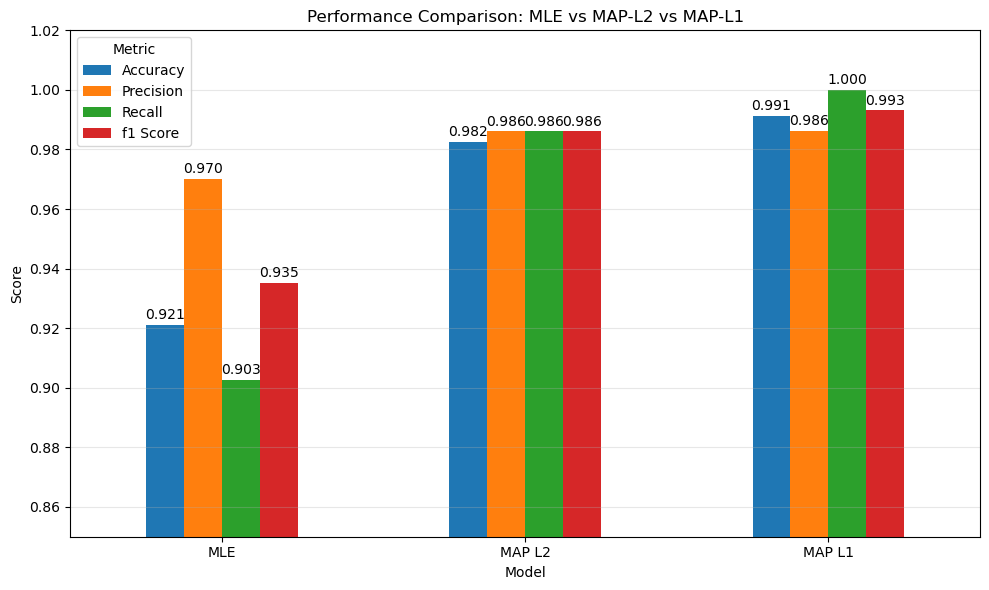

In [55]:
ax=results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Performance Comparison: MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)

for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)

plt.tight_layout()
plt.show()

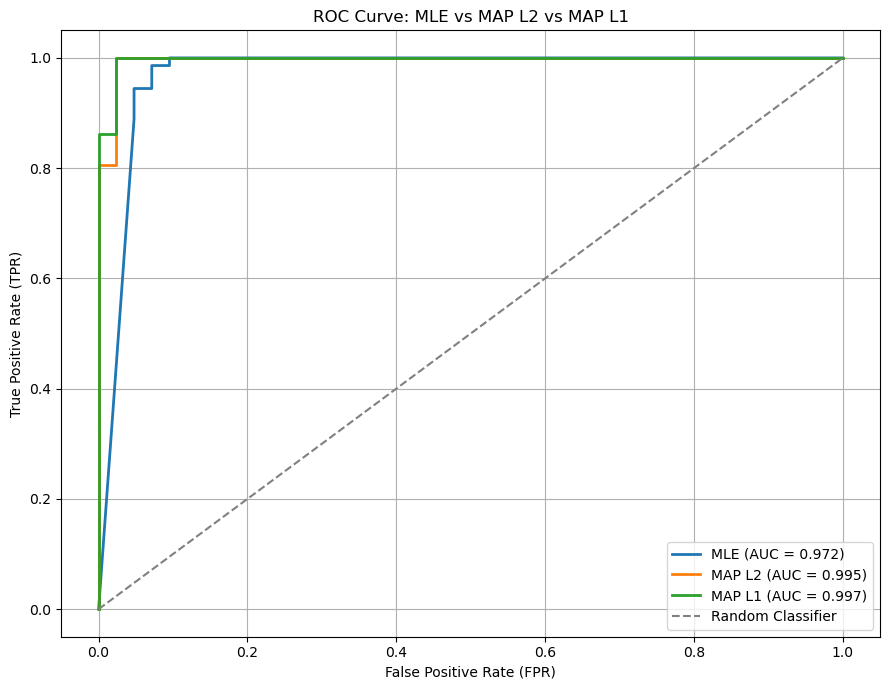

In [59]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

for name, model, pred in models:

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Plot random classifier once
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()